# Correlation × Concentration Sweep

How does the similarity between burst functions and pretrain functions affect forgetting?

- **Correlation 0%**: all burst functions are completely novel bijections
- **Correlation 100%**: burst functions are copies of the pretrain-slot functions (same mapping, new token)
- Swept against burst concentration (fraction of burst data in each FT batch)

In [1]:
import sys, os, importlib
os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")

import simple.model, simple.data, simple.pretrain, simple.finetune, simple.forget, simple.report
for name in ["simple.model", "simple.data", "simple.pretrain", "simple.finetune",
             "simple.forget", "simple.report"]:
    importlib.reload(sys.modules[name])

from simple import make_data, pretrain, report
from simple.finetune import _finetune_worker
from simple.forget import _forget_worker
import torch.multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt
import pickle
%matplotlib inline

SEED = 42

In [ ]:
# ── Sweep grid ──────────────────────────────────────────
CORRELATIONS = [0.0, 0.25, 0.5, 0.75, 1.0]
FRACS = [1.0, 0.95, 0.9, 0.7, 0.5, 0.3]
SEEDS = [42, 123, 777, 945]

FT_STEPS = 1500
FG_STEPS = 800
FT_LR = 1e-4
FG_LR = 1e-4
BATCH_SIZE = 512
EVAL_EVERY = 50
OUT = "data/corr_conc_sweep"

n_corr, n_frac, n_seeds = len(CORRELATIONS), len(FRACS), len(SEEDS)
print(f"Grid: {n_corr} corrs × {n_frac} fracs × {n_seeds} seeds = {n_corr * n_frac * n_seeds} FT+FG runs")

Grid: 5 corrs × 6 fracs × 3 seeds = 90 FT+FG runs


In [3]:
# ── Run full sweep (corr × frac × seed) ──
ctx = mp.get_context("spawn")
n_workers = min(n_frac * n_seeds, 12)

# all_ft[corr][seed] = list of ft results (one per frac)
# all_fg[corr][seed] = list of fg results (one per frac)
all_ft = {c: {} for c in CORRELATIONS}
all_fg = {c: {} for c in CORRELATIONS}

for corr in CORRELATIONS:
    for seed in SEEDS:
        print(f"\n{'='*60}")
        print(f"Correlation={corr:.0%}  seed={seed}")

        data = make_data(depth=3, burst_pos=3, n_a=4, n_burst=4,
                         burst_correlation=corr, seed=seed)

        pt_dir = f"{OUT}/pretrain_corr{int(corr*100)}_s{seed}"
        pt = pretrain(data, pt_dir, seed=seed, batch_size=BATCH_SIZE, quiet=True)
        print(f"  PT done: {pt['ckpt_path']}")

        # FT: all fracs in parallel
        ft_jobs = [dict(data=data, pretrain_ckpt=pt["ckpt_path"],
                        out_dir=f"{OUT}/finetune",
                        burst_frac=frac, steps=FT_STEPS, lr=FT_LR,
                        batch_size=BATCH_SIZE, eval_every=EVAL_EVERY,
                        tag=f"corr{int(corr*100)}_b{int(frac*100)}_s{seed}",
                        seed=seed, quiet=True, lite=True)
                   for frac in FRACS]

        with ctx.Pool(min(n_workers, len(ft_jobs))) as pool:
            ft_results = pool.map(_finetune_worker, ft_jobs)
        all_ft[corr][seed] = ft_results

        # FG: all fracs in parallel
        fg_jobs = [dict(data=data, finetune_ckpt=ft_r["ckpt_path"],
                        pretrain_ckpt=pt["ckpt_path"],
                        out_dir=f"{OUT}/forget",
                        steps=FG_STEPS, lr=FG_LR,
                        batch_size=BATCH_SIZE, eval_every=EVAL_EVERY,
                        tag=ft_r["tag"], seed=seed, quiet=True, lite=True)
                   for ft_r in ft_results]

        with ctx.Pool(min(n_workers, len(fg_jobs))) as pool:
            fg_results = pool.map(_forget_worker, fg_jobs)
        all_fg[corr][seed] = fg_results

        for ft_r, fg_r in zip(ft_results, fg_results):
            print(f"    {ft_r['tag']}: peak={ft_r['peak_burst']:.3f} drop={fg_r['dropoff_pct']:.1f}%")

# Save
with open(f"{OUT}/sweep_results.pkl", "wb") as f:
    pickle.dump({"all_ft": all_ft, "all_fg": all_fg,
                 "CORRELATIONS": CORRELATIONS, "FRACS": FRACS, "SEEDS": SEEDS,
                 "FT_STEPS": FT_STEPS, "FG_STEPS": FG_STEPS}, f)
print(f"\nSaved to {OUT}/sweep_results.pkl")


Correlation=0%  seed=42
  PT done: data/corr_conc_sweep/pretrain_corr0_s42/pretrain_ckpt.pt
    corr0_b100_s42: peak=1.000 drop=83.2%
    corr0_b95_s42: peak=1.000 drop=55.5%
    corr0_b90_s42: peak=1.000 drop=51.0%
    corr0_b70_s42: peak=1.000 drop=37.7%
    corr0_b50_s42: peak=1.000 drop=26.6%
    corr0_b30_s42: peak=1.000 drop=23.5%

Correlation=0%  seed=123
  PT done: data/corr_conc_sweep/pretrain_corr0_s123/pretrain_ckpt.pt
    corr0_b100_s123: peak=1.000 drop=81.2%
    corr0_b95_s123: peak=1.000 drop=48.6%
    corr0_b90_s123: peak=1.000 drop=38.2%
    corr0_b70_s123: peak=1.000 drop=25.8%
    corr0_b50_s123: peak=1.000 drop=20.1%
    corr0_b30_s123: peak=1.000 drop=19.5%

Correlation=0%  seed=777
  PT done: data/corr_conc_sweep/pretrain_corr0_s777/pretrain_ckpt.pt
    corr0_b100_s777: peak=1.000 drop=82.2%
    corr0_b95_s777: peak=1.000 drop=39.5%
    corr0_b90_s777: peak=1.000 drop=47.2%
    corr0_b70_s777: peak=1.000 drop=19.7%
    corr0_b50_s777: peak=1.000 drop=25.0%
    co

In [4]:
# ── Load saved results (uncomment to skip training) ──
# with open(f"{OUT}/sweep_results.pkl", "rb") as f:
#     saved = pickle.load(f)
# all_ft, all_fg = saved["all_ft"], saved["all_fg"]
# CORRELATIONS, FRACS, SEEDS = saved["CORRELATIONS"], saved["FRACS"], saved["SEEDS"]
# n_corr, n_frac, n_seeds = len(CORRELATIONS), len(FRACS), len(SEEDS)
# print(f"Loaded: {n_corr} corrs × {n_frac} fracs × {n_seeds} seeds")

In [ ]:
# ── Extract metrics into grids: mean ± std across seeds ──
def _extract_metric(all_ft, all_fg, corr, i_f, fn):
    """Extract a scalar metric for each seed, return list."""
    return [fn(all_ft[corr][s][i_f], all_fg[corr][s][i_f]) for s in SEEDS]

metric_fns = {
    "peak_burst":    lambda ft, fg: ft["peak_burst"],
    "drop_pct":      lambda ft, fg: fg["dropoff_pct"],
    "reversion_auc": lambda ft, fg: fg["reversion_auc"],
    "ft_bg_acc":     lambda ft, fg: ft["log"]["acc_other"][-1],
    "ft_bg_loss":    lambda ft, fg: ft["log"]["loss_other"][-1],
    "ft_burst_acc":  lambda ft, fg: ft["log"]["acc_burst"][-1],
    "fg_burst_acc":  lambda ft, fg: fg["log"]["acc_burst"][-1],
    "fg_bg_acc":     lambda ft, fg: fg["log"]["acc_other"][-1],
}

grids_mean = {}
grids_std = {}
for name, fn in metric_fns.items():
    mean = np.zeros((n_corr, n_frac))
    std = np.zeros((n_corr, n_frac))
    for i_c, corr in enumerate(CORRELATIONS):
        for i_f in range(n_frac):
            vals = _extract_metric(all_ft, all_fg, corr, i_f, fn)
            mean[i_c, i_f] = np.mean(vals)
            std[i_c, i_f] = np.std(vals)
    grids_mean[name] = mean
    grids_std[name] = std

print(f"Metrics extracted ({n_seeds} seeds averaged).")

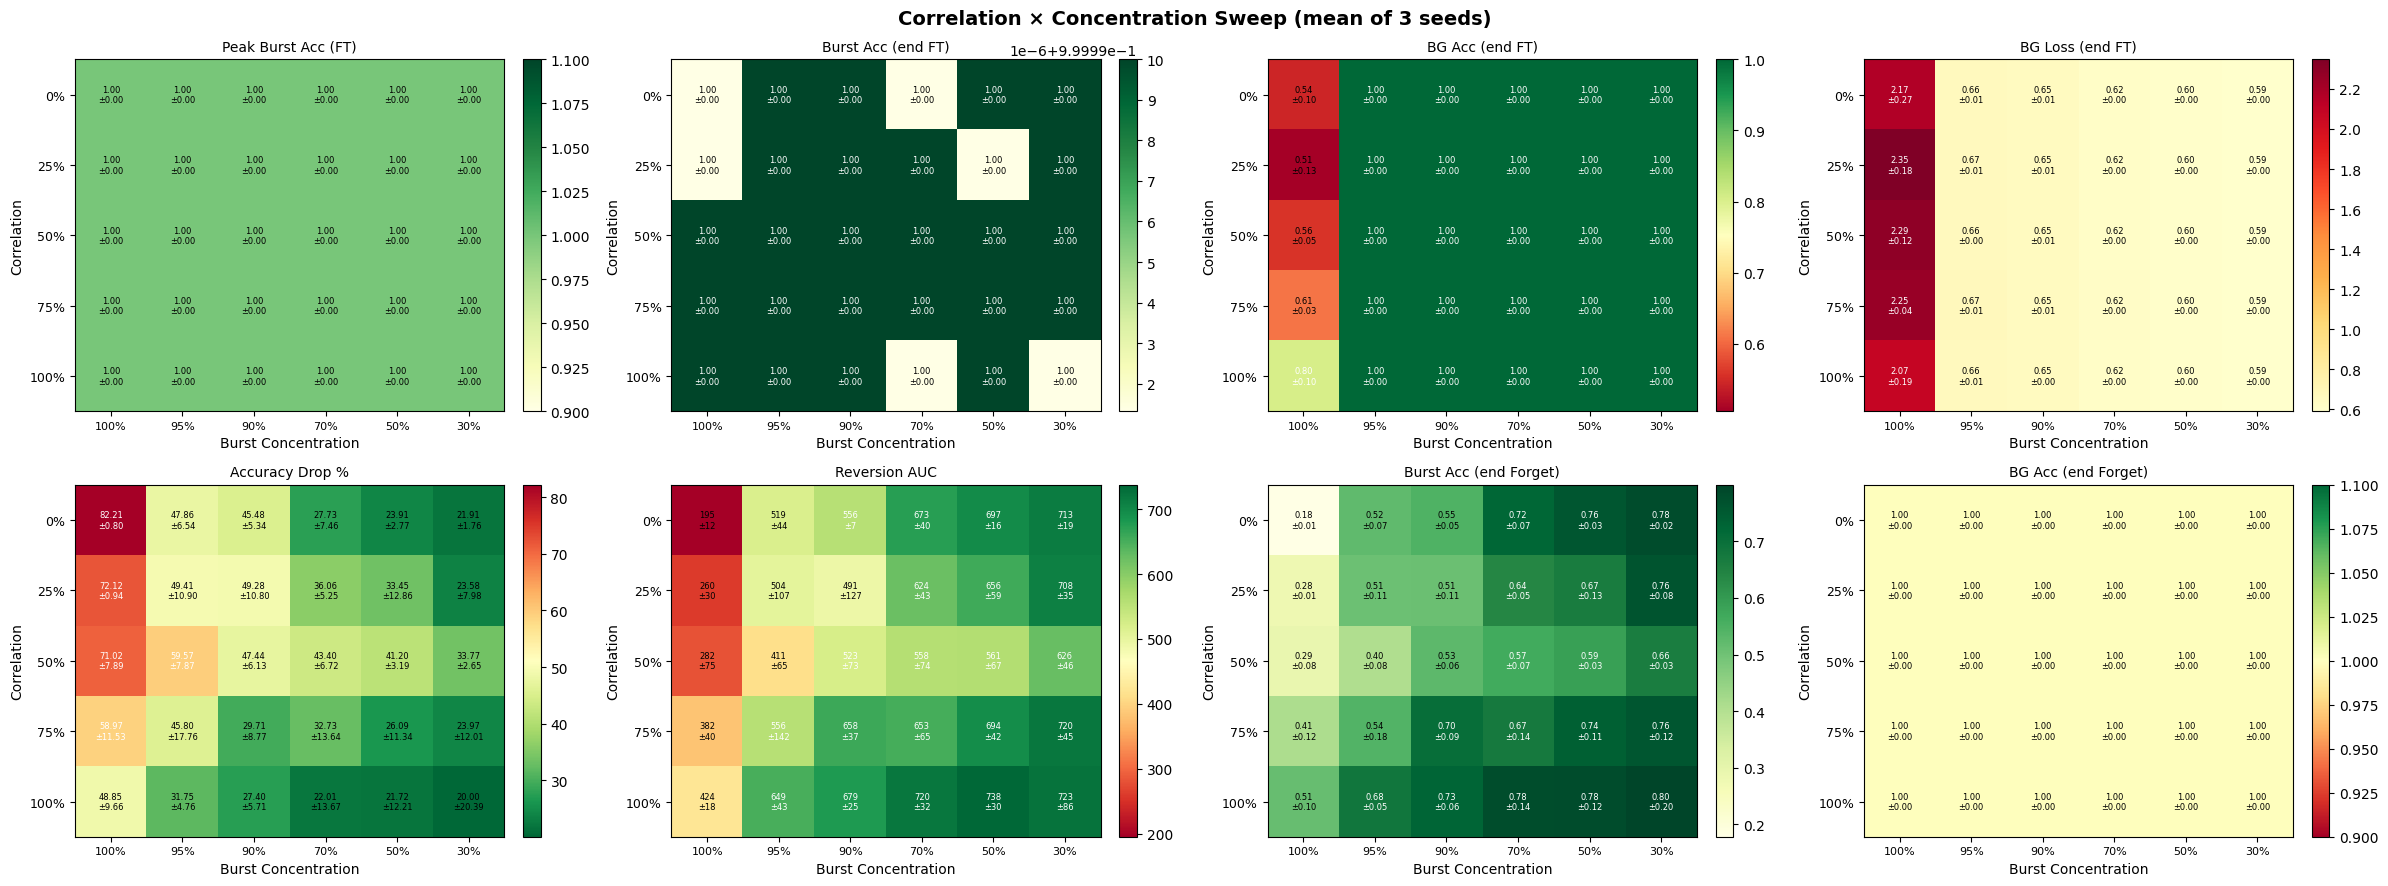

In [6]:
# ── Heatmaps (mean values, annotated with mean±std) ──
corr_labels = [f"{int(c*100)}%" for c in CORRELATIONS]
frac_labels = [f"{int(f*100)}%" for f in FRACS]

heatmap_defs = [
    ("Peak Burst Acc (FT)", "peak_burst", "YlGn"),
    ("Burst Acc (end FT)", "ft_burst_acc", "YlGn"),
    ("BG Acc (end FT)", "ft_bg_acc", "RdYlGn"),
    ("BG Loss (end FT)", "ft_bg_loss", "YlOrRd"),
    ("Accuracy Drop %", "drop_pct", "RdYlGn_r"),
    ("Reversion AUC", "reversion_auc", "RdYlGn"),
    ("Burst Acc (end Forget)", "fg_burst_acc", "YlGn"),
    ("BG Acc (end Forget)", "fg_bg_acc", "RdYlGn"),
]

n_cols = 4
n_rows = (len(heatmap_defs) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes = axes.flatten()

for idx, (title, key, cmap) in enumerate(heatmap_defs):
    ax = axes[idx]
    grid = grids_mean[key]
    im = ax.imshow(grid, aspect="auto", cmap=cmap)
    ax.set_xticks(range(n_frac)); ax.set_xticklabels(frac_labels, fontsize=8)
    ax.set_yticks(range(n_corr)); ax.set_yticklabels(corr_labels, fontsize=9)
    ax.set_xlabel("Burst Concentration")
    ax.set_ylabel("Correlation")
    ax.set_title(title, fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(n_corr):
        for j in range(n_frac):
            m = grids_mean[key][i, j]
            s = grids_std[key][i, j]
            txt = f"{m:.2f}\n±{s:.2f}" if abs(m) < 100 else f"{m:.0f}\n±{s:.0f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=6,
                    color="white" if abs(m - grid.min()) > 0.6 * (grid.max() - grid.min()) else "black")

for idx in range(len(heatmap_defs), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(f"Correlation × Concentration Sweep (mean of {n_seeds} seeds)",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

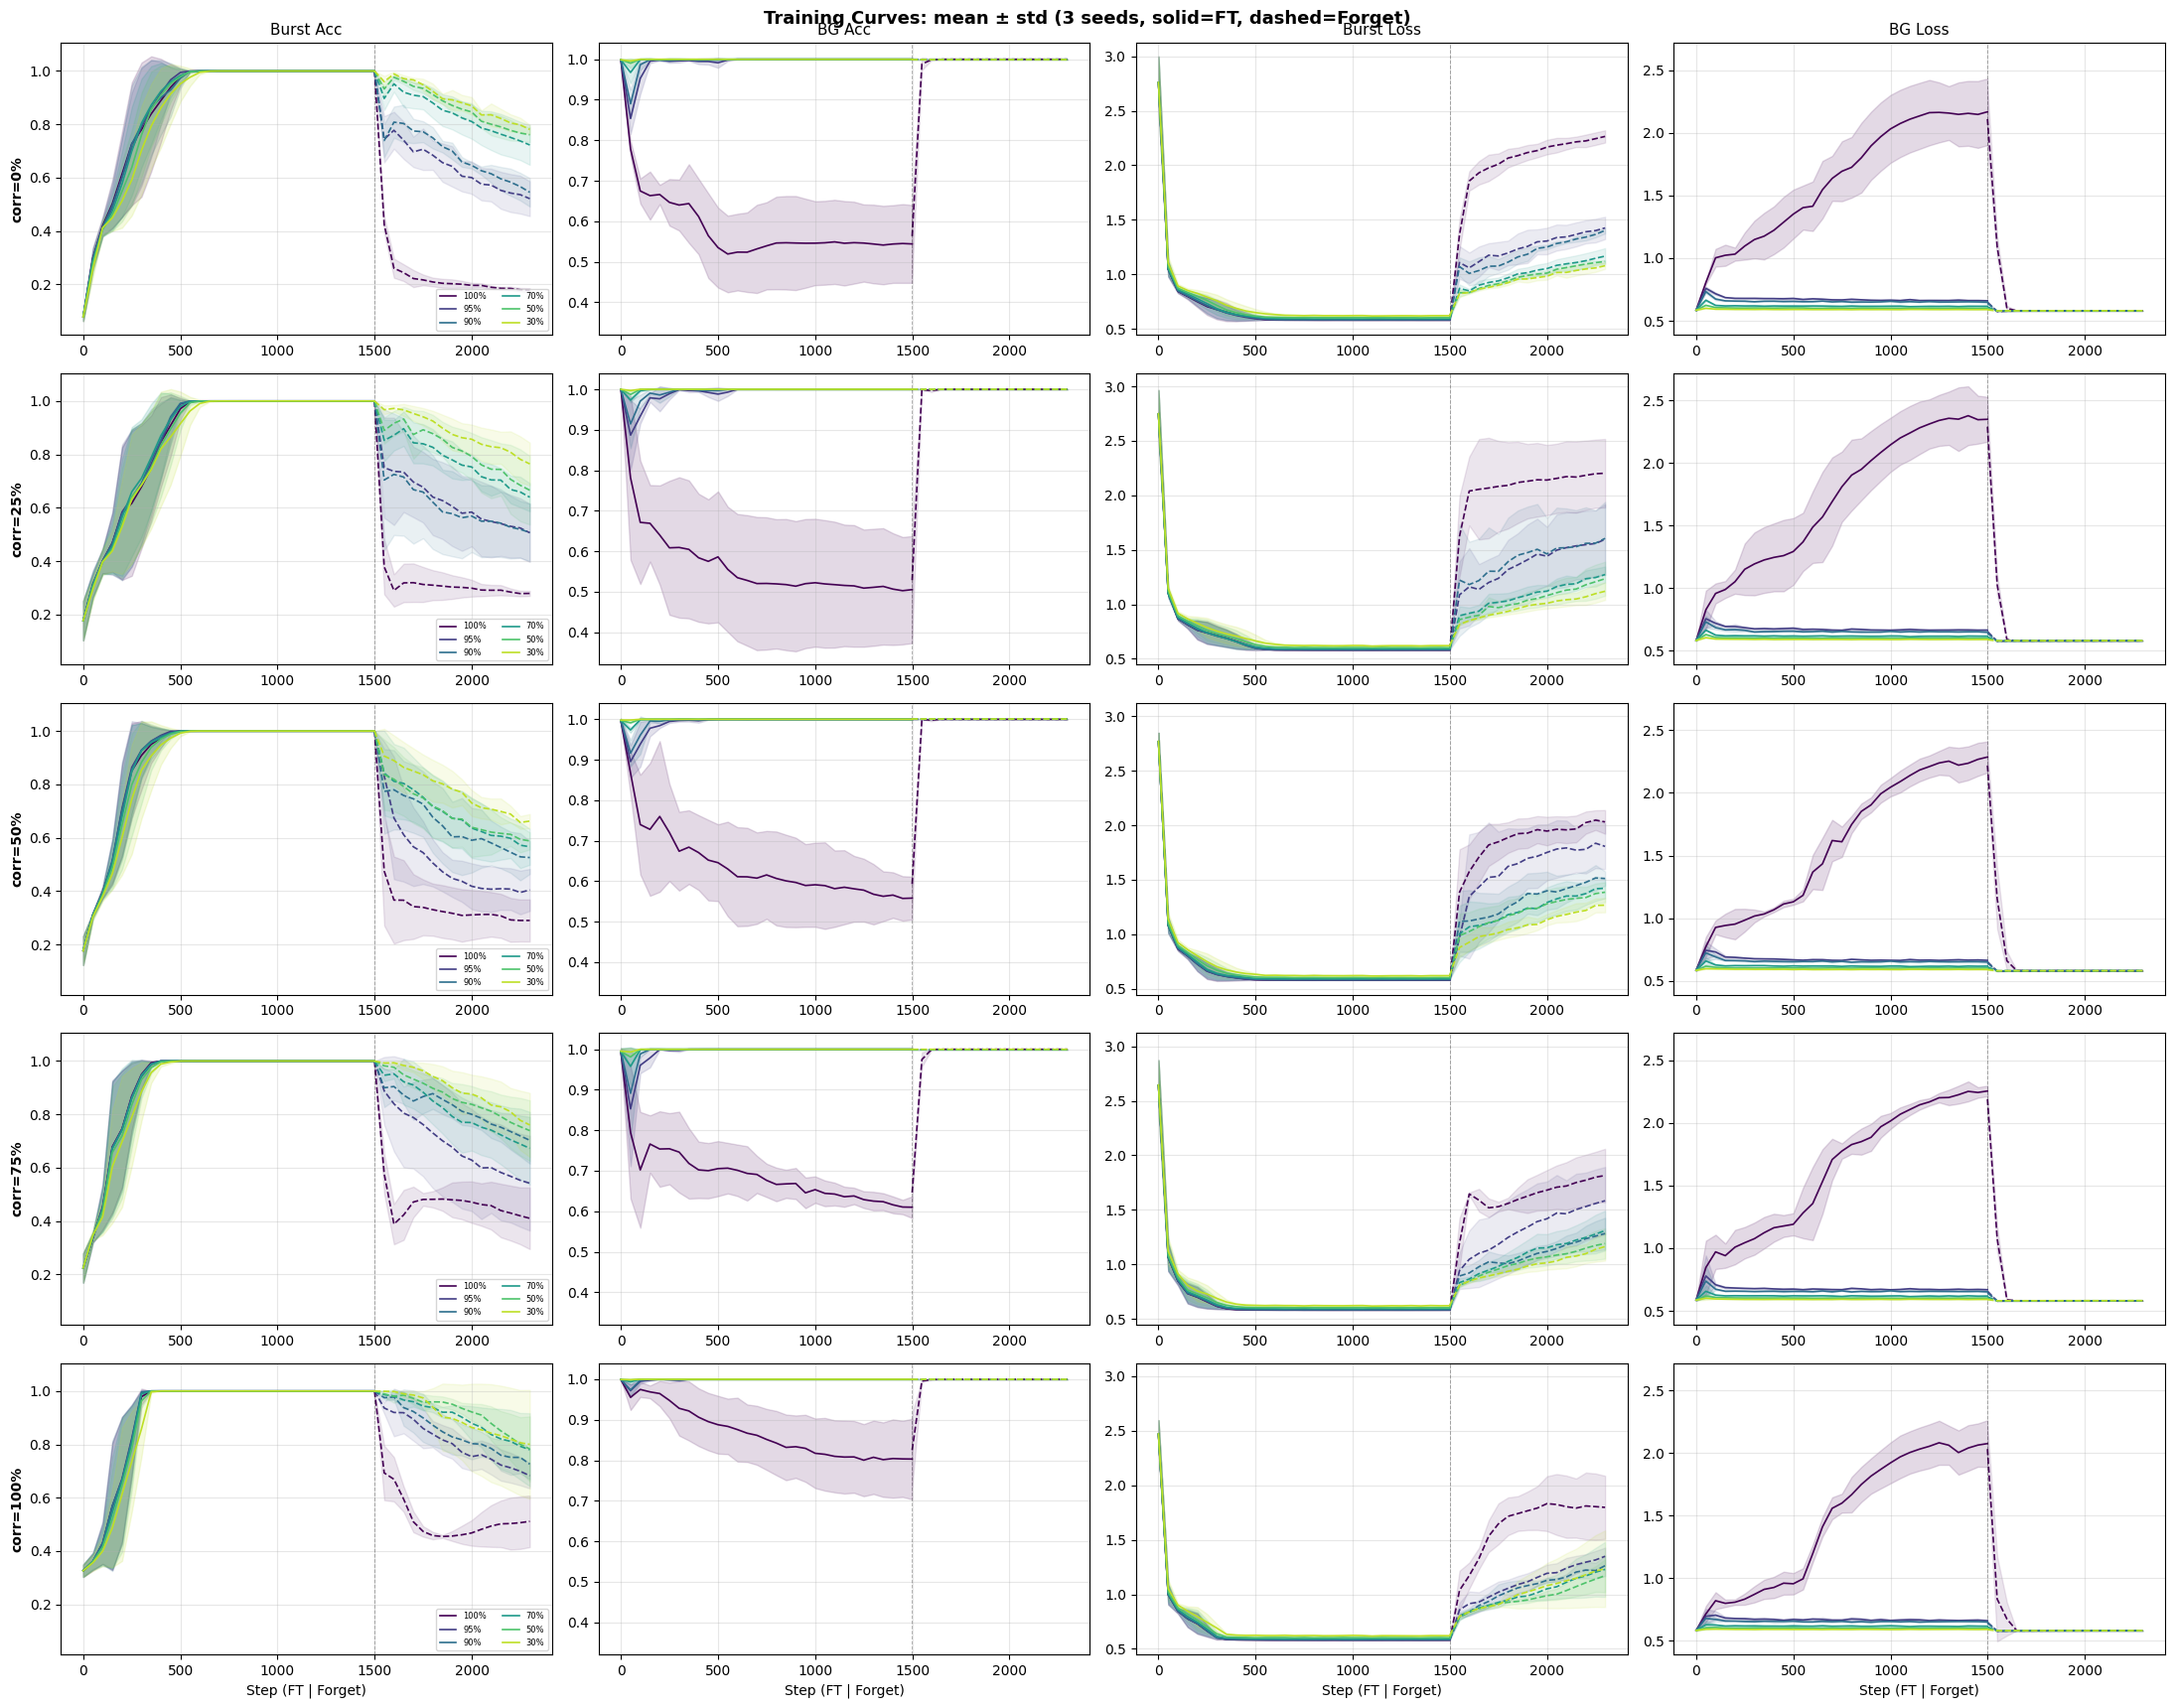

In [7]:
# ── Training curves: mean across seeds with shaded std ──
# One row per correlation, cols = burst acc, bg acc, burst loss, bg loss
frac_colors = plt.cm.viridis(np.linspace(0, 0.9, n_frac))

fig, axes = plt.subplots(n_corr, 4, figsize=(22, 3.5 * n_corr), sharey='col')
if n_corr == 1:
    axes = axes[np.newaxis, :]

for i_c, corr in enumerate(CORRELATIONS):
    for i_f, frac in enumerate(FRACS):
        c = frac_colors[i_f]
        label = f"{int(frac*100)}%"

        # Collect curves across seeds for FT and FG
        for col, key in enumerate(["acc_burst", "acc_other", "loss_burst", "loss_other"]):
            ax = axes[i_c, col]
            # FT
            ft_curves = [all_ft[corr][s][i_f]["log"][key] for s in SEEDS]
            ft_steps = all_ft[corr][SEEDS[0]][i_f]["log"]["step"]
            min_len_ft = min(len(c_) for c_ in ft_curves)
            ft_arr = np.array([c_[:min_len_ft] for c_ in ft_curves])
            ft_mean = ft_arr.mean(0)
            ft_std = ft_arr.std(0)
            ax.plot(ft_steps[:min_len_ft], ft_mean, color=c, linewidth=1.2,
                    label=label if col == 0 else None)
            ax.fill_between(ft_steps[:min_len_ft], ft_mean - ft_std, ft_mean + ft_std,
                            color=c, alpha=0.15)

            # FG
            fg_curves = [all_fg[corr][s][i_f]["log"][key] for s in SEEDS]
            fg_steps_raw = all_fg[corr][SEEDS[0]][i_f]["log"]["step"]
            ft_end = ft_steps[-1] if ft_steps else 0
            min_len_fg = min(len(c_) for c_ in fg_curves)
            fg_arr = np.array([c_[:min_len_fg] for c_ in fg_curves])
            fg_mean = fg_arr.mean(0)
            fg_std = fg_arr.std(0)
            fg_s = [s + ft_end for s in fg_steps_raw[:min_len_fg]]
            ax.plot(fg_s, fg_mean, color=c, linewidth=1.2, linestyle="--")
            ax.fill_between(fg_s, fg_mean - fg_std, fg_mean + fg_std,
                            color=c, alpha=0.1)

            if i_f == 0:
                ax.axvline(ft_end, color="black", linewidth=0.7, linestyle="--", alpha=0.3)

    axes[i_c, 0].set_ylabel(f"corr={int(corr*100)}%", fontsize=10, fontweight="bold")
    axes[i_c, 0].legend(fontsize=6, loc="lower right", ncol=2)

for col, title in enumerate(["Burst Acc", "BG Acc", "Burst Loss", "BG Loss"]):
    axes[0, col].set_title(title, fontsize=11)
    axes[-1, col].set_xlabel("Step (FT | Forget)")
    for i_c in range(n_corr):
        axes[i_c, col].grid(True, alpha=0.3)

fig.suptitle(f"Training Curves: mean ± std ({n_seeds} seeds, solid=FT, dashed=Forget)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

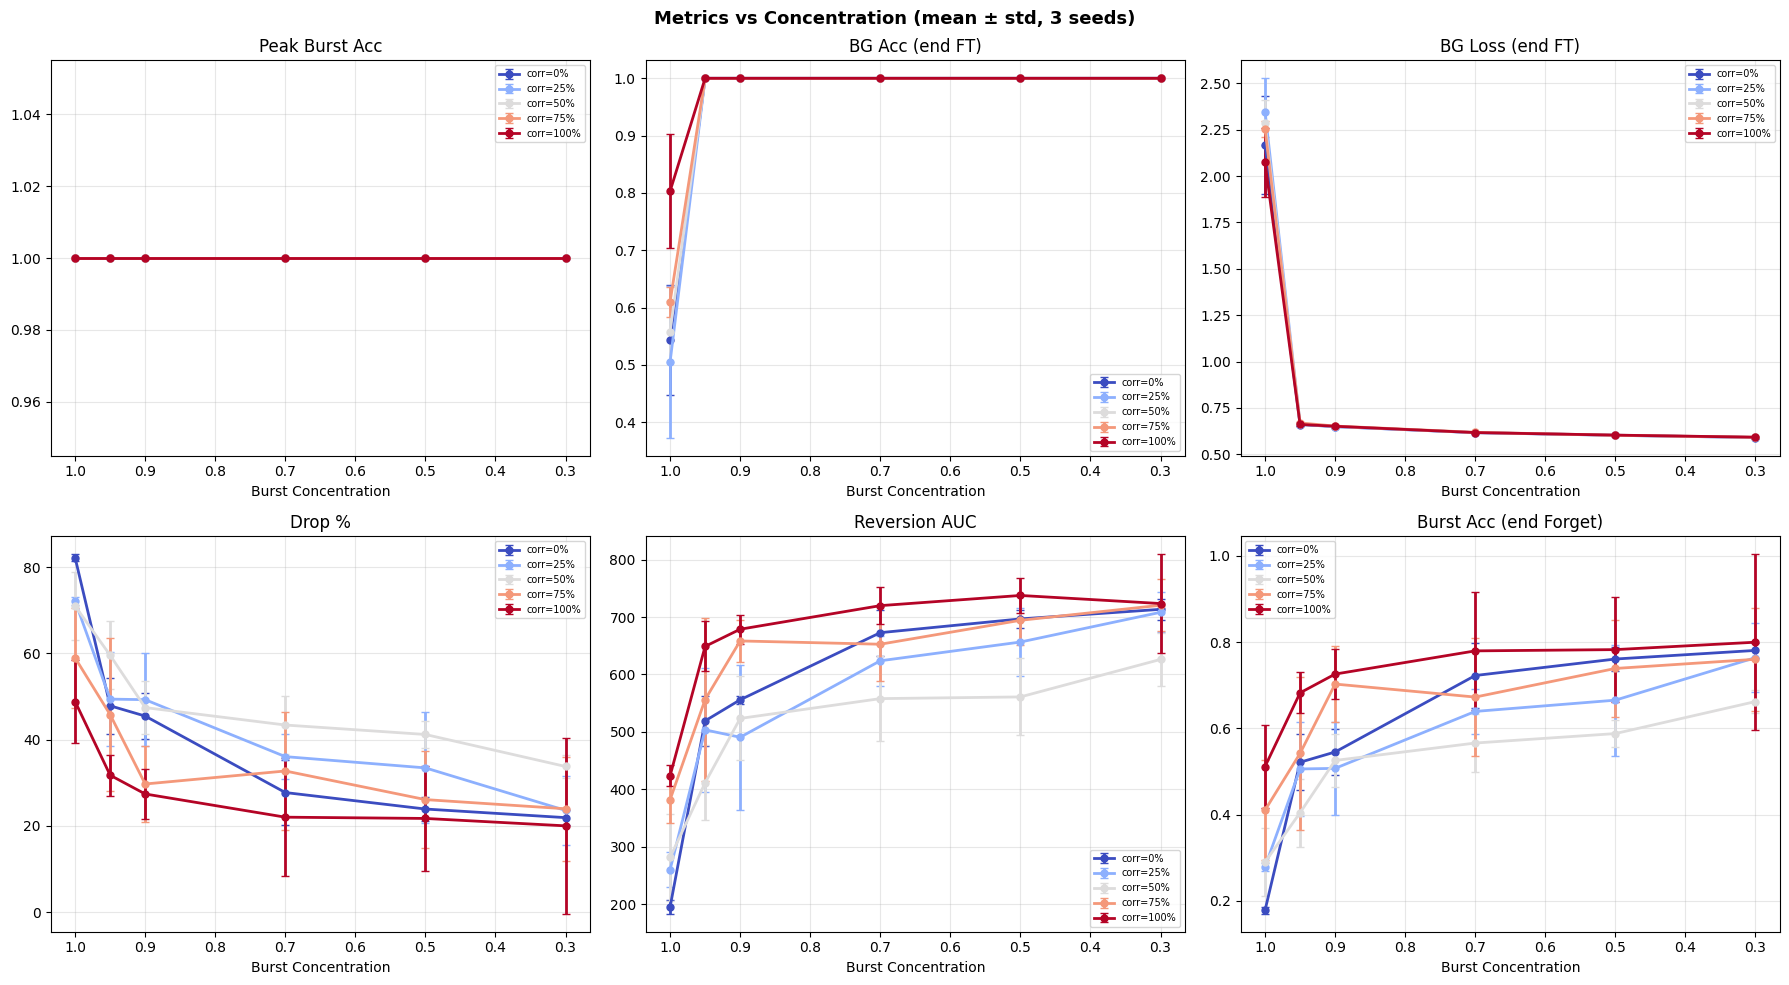

In [8]:
# ── Line plots: metrics vs concentration, one line per correlation, with error bars ──
corr_colors = plt.cm.coolwarm(np.linspace(0, 1, n_corr))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

line_metrics = [
    ("Peak Burst Acc", "peak_burst", axes[0, 0]),
    ("BG Acc (end FT)", "ft_bg_acc", axes[0, 1]),
    ("BG Loss (end FT)", "ft_bg_loss", axes[0, 2]),
    ("Drop %", "drop_pct", axes[1, 0]),
    ("Reversion AUC", "reversion_auc", axes[1, 1]),
    ("Burst Acc (end Forget)", "fg_burst_acc", axes[1, 2]),
]

for title, key, ax in line_metrics:
    for i_c, corr in enumerate(CORRELATIONS):
        m = grids_mean[key][i_c]
        s = grids_std[key][i_c]
        ax.errorbar(FRACS, m, yerr=s, fmt="o-", color=corr_colors[i_c],
                    label=f"corr={int(corr*100)}%", linewidth=2,
                    markersize=5, capsize=3)
    ax.set_xlabel("Burst Concentration")
    ax.set_title(title)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax.invert_xaxis()

fig.suptitle(f"Metrics vs Concentration (mean ± std, {n_seeds} seeds)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

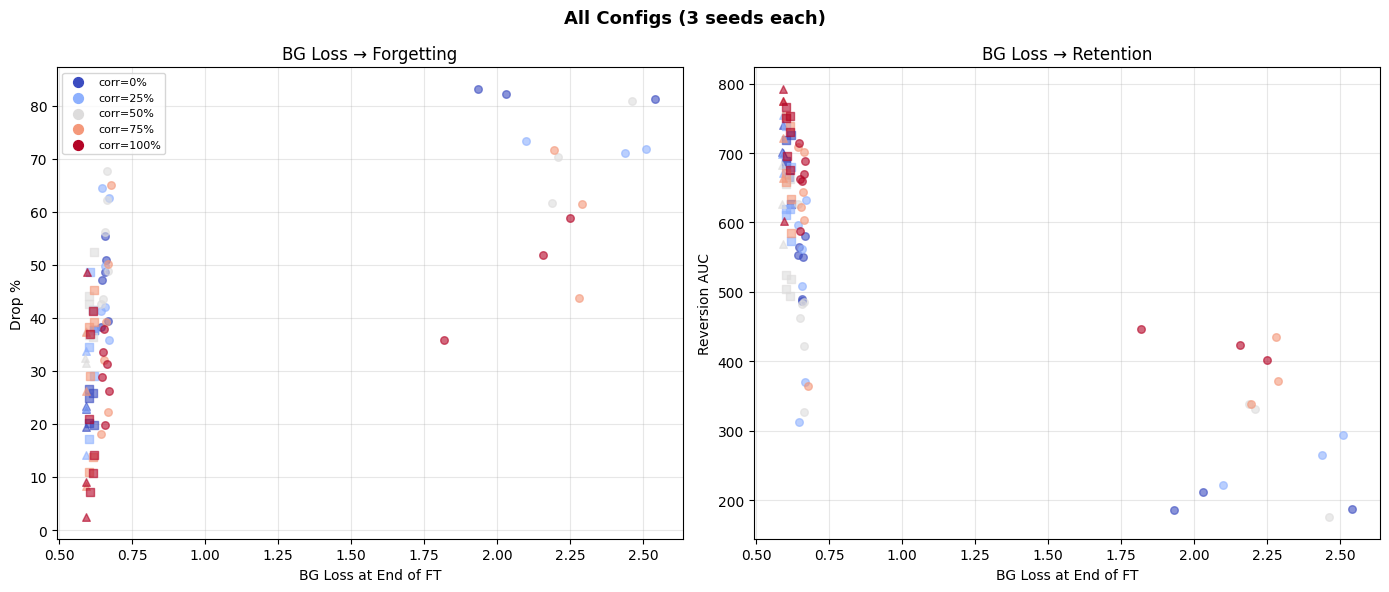

In [9]:
# ── Scatter: BG loss at end of FT vs forgetting (all seeds shown, colored by correlation) ──
corr_colors = plt.cm.coolwarm(np.linspace(0, 1, n_corr))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for i_c, corr in enumerate(CORRELATIONS):
    color = corr_colors[i_c]
    for i_f, frac in enumerate(FRACS):
        for seed in SEEDS:
            ft_r = all_ft[corr][seed][i_f]
            fg_r = all_fg[corr][seed][i_f]
            bg_loss = ft_r["log"]["loss_other"][-1]
            marker = "o" if frac >= 0.9 else ("s" if frac >= 0.5 else "^")
            ax1.scatter(bg_loss, fg_r["dropoff_pct"], c=[color], marker=marker,
                        s=30, zorder=3, alpha=0.6)
            ax2.scatter(bg_loss, fg_r["reversion_auc"], c=[color], marker=marker,
                        s=30, zorder=3, alpha=0.6)

for i_c, corr in enumerate(CORRELATIONS):
    ax1.scatter([], [], c=[corr_colors[i_c]], label=f"corr={int(corr*100)}%", s=50)

ax1.set_xlabel("BG Loss at End of FT"); ax1.set_ylabel("Drop %")
ax1.set_title("BG Loss → Forgetting"); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
ax2.set_xlabel("BG Loss at End of FT"); ax2.set_ylabel("Reversion AUC")
ax2.set_title("BG Loss → Retention"); ax2.grid(True, alpha=0.3)
fig.suptitle(f"All Configs ({n_seeds} seeds each)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()